In [1]:
## Import Dependencies
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import easydict
from tqdm.notebook import tqdm
from sklearn.covariance import LedoitWolf

import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

In [2]:
from google.colab import files

## 파일 업로드
uploaded = files.upload()

Saving chemical_process_timeseries.csv to chemical_process_timeseries.csv


In [3]:
## 데이터 불러오기
df = pd.read_csv("chemical_process_timeseries.csv")

## 데이터 확인
df.head()

,timestamp,operating_regime,reactor_id,ambient_temp_effect,reactor_temp,reactor_pressure,feed_flow_rate,coolant_flow_rate,agitator_speed_rpm,reaction_rate,...,selectivity,yield_pct,vibration_rms,motor_current,power_consumption_kw,temp_setpoint,pressure_setpoint,fault_type,efficiency_loss_pct,time_to_fault_min
0,2024-01-01 00:00:00,A,A_R1,0.000000,181.135558,15.791013,101.108882,79.154645,305.779931,0.724542,...,91.927424,82.032893,1.470297,45.882315,41.294083,180.0,12.0,0,0.0,NaN
1,2024-01-01 00:01:00,A,A_R1,0.000485,182.249820,15.706975,98.932369,NaN,302.283603,0.728999,...,91.581466,81.301503,1.425847,46.755905,42.080314,180.0,12.0,0,0.0,NaN
2,2024-01-01 00:02:00,A,A_R1,0.000970,183.129737,15.593397,99.792219,80.593736,305.814440,0.732519,...,91.895056,82.006626,1.448190,NaN,NaN,NaN,12.0,0,NaN,NaN
3,2024-01-01 00:03:00,A,A_R1,0.001454,183.020987,15.527333,99.854222,80.190444,304.436123,0.732084,...,91.544885,81.562261,1.473448,45.862171,41.275954,180.0,12.0,0,0.0,NaN
4,2024-01-01 00:04:00,A,A_R1,0.001939,183.077096,NaN,99.302349,78.571707,304.811418,0.732308,...,92.258005,82.411124,1.523491,46.880227,42.192204,180.0,12.0,0,NaN,NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 777600 entries, 0 to 777599
Data columns (total 21 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   timestamp             777600 non-null  object 
 1   operating_regime      777600 non-null  object 
 2   reactor_id            777600 non-null  object 
 3   ambient_temp_effect   731039 non-null  float64
 4   reactor_temp          730635 non-null  float64
 5   reactor_pressure      730457 non-null  float64
 6   feed_flow_rate        730840 non-null  float64
 7   coolant_flow_rate     730955 non-null  float64
 8   agitator_speed_rpm    730825 non-null  float64
 9   reaction_rate         730770 non-null  float64
 10  conversion_rate       731184 non-null  float64
 11  selectivity           730391 non-null  float64
 12  yield_pct             731076 non-null  float64
 13  vibration_rms         731141 non-null  float64
 14  motor_current         730983 non-null  float64
 15  

### 데이터 전처리

In [5]:
## 데이터 Type 변경
df['timestamp'] = pd.to_datetime(df['timestamp'])

## Reactor별 시간 순서 정렬
df = df.sort_values(['reactor_id', 'timestamp'])

## timestamp를 index로 변환
df = df.set_index('timestamp')

In [6]:
features = [
    "reactor_temp", "reactor_pressure", "feed_flow_rate", "coolant_flow_rate",
    "agitator_speed_rpm", "vibration_rms", "motor_current", "power_consumption_kw"
]

<Axes: >

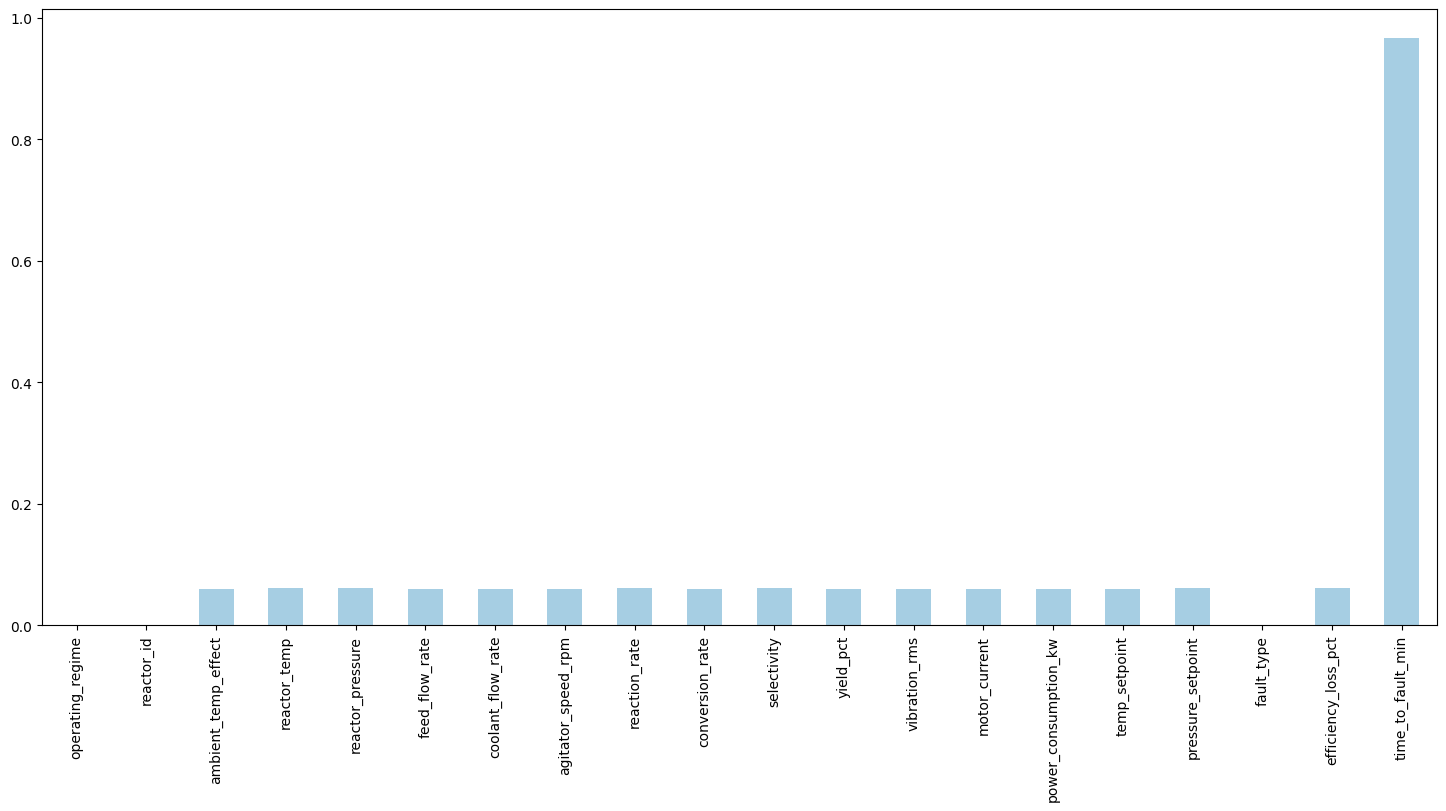

In [7]:
## 결측 변수 확인
(df.isnull().sum()/len(df)).plot.bar(figsize=(18,8), colormap='Paired')

In [8]:
## 이전 시점의 데이터로 보간
df[features] = df.groupby('reactor_id')[features].ffill().bfill()

### 데이터 분리 및 정규화

In [9]:
## 리액터별로 고장과 정상 데이터가 몇 개씩 있는지 확인
breakdown = df.groupby(['reactor_id', df['fault_type'] != 0]).size().unstack(fill_value=0)
breakdown.columns = ['Normal (0)', 'Fault (1)']
print(breakdown)

            Normal (0)  Fault (1)
reactor_id                       
A_R1            123282       6318
A_R2            126602       2998
A_R3            124922       4678
B_R1            123792       5808
B_R2            127148       2452
B_R3            123953       5647


In [10]:
## 정상 데이터와 비정상 데이터 분리하여 학습, 검증, 테스트
normal_df = df[df['fault_type'] == 0]
abnormal_df = df[df['fault_type'] != 0]

In [11]:
## reactor별 시간 순서 유지한 상태로 정상 데이터 split
train_list = []
val_list = []
test_list = []

## reactor별 반복
for reactor_id, reactor_df in normal_df.groupby('reactor_id'):
  reactor_df = reactor_df.sort_index()

  ## 데이터 길이
  n = len(reactor_df)

  ## 70/15/15 split
  train_end = int(n * 0.7)
  val_end = int(n * 0.85)

  ## 시간 기준 split
  train_part = reactor_df.iloc[:train_end]
  val_part = reactor_df.iloc[train_end:val_end]
  test_part = reactor_df.iloc[val_end:]

  ## 리스트에 저장
  train_list.append(train_part)
  val_list.append(val_part)
  test_list.append(test_part)

## reactor별 분할된 데이터 합치기
train_normal = pd.concat(train_list)
val_normal = pd.concat(val_list)
test_normal = pd.concat(test_list)

## abnormal 데이터는 전체를 테스트에 사용
test_abnormal = abnormal_df.copy()

In [12]:
## 데이터 정규화를 위하여 분산 및 평균 추출
mean_df = train_normal[features].mean()
std_df = train_normal[features].std()

### 데이터 구조 만들기

In [13]:
## 데이터를 불러올 때 index로 불러오기
def make_data_idx(df, window_size=60):

  input_idx = []

  df_reset = df.reset_index()

  ## reactor별로 그룹화하여 데이터가 섞이지 않게 함
  for reactor_id, group in df_reset.groupby('reactor_id'):

    group = group.sort_values('timestamp') # 시간 정렬

    indices = group.index.tolist()
    timestamps = group['timestamp'].values # timestamps 추출

		## sliding window 생성
    for i in range(len(group) - window_size + 1):

      start_time = timestamps[i]
      end_time = timestamps[i + window_size - 1]

      ## 정확히 1분 간격인지 확인
      diff = (
          pd.Timestamp(end_time) - pd.Timestamp(start_time)
      ).total_seconds() / 60

      if diff == (window_size - 1):

        seq_idx = indices[i:i+window_size]
        input_idx.append(seq_idx)

  return input_idx

In [14]:
## Dataset을 상속받아 데이터 구성
class ChemicalDataset(Dataset):
  def __init__(self, input_size, df, mean_df=None, std_df=None, window_size=60):

    self.input_size = input_size
    self.window_size = window_size

    temp_df = df.copy()

    ## 정규화
    if mean_df is not None:
      temp_df[features] = (temp_df[features] - mean_df) / std_df

    ## 연속한 index를 기준으로 학습에 사용
    self.input_ids = make_data_idx(temp_df, window_size)

    ## sensor 데이터만 사용하여 reconstruct에 활용
    self.features = features[:input_size]
    self.var_data = torch.tensor(temp_df[self.features].values, dtype=torch.float)

    ## metadate 저장
    self.meta_df = temp_df.reset_index()

  ## Dataset은 반드시 __len__ 함수를 만들어줘야함
  ## sequence 개수 반환
  def __len__(self):
    return len(self.input_ids)

  ## Dataset은 반드시 __getitem__ 함수를 만들어줘야함
  ## torch 모듈은 __getitem__ 을 호출하여 학습할 데이터를 불러옴
  def __getitem__(self, idx):
    seq_idx = self.input_ids[idx]
    x = self.var_data[seq_idx]
    return x

### 모델 구성하기

In [15]:
## 인코더
class Encoder(nn.Module):

  def __init__(self, input_size, hidden_size, num_layers=2):

    super().__init__()

    self.lstm = nn.LSTM(
        input_size=input_size,
        hidden_size=hidden_size,
        num_layers=num_layers,
        batch_first=True,
        dropout=0.1
    )

  def forward(self, x):
    _, (hidden, cell) = self.lstm(x)

    ## 마지막 layer latent
    latent = hidden[-1]

    return hidden, cell, latent

In [16]:
## 디코더
class Decoder(nn.Module):

  def __init__(self, input_size, hidden_size, output_size, num_layers=2):
    super(Decoder, self).__init__()

    self.lstm = nn.LSTM(
        input_size=input_size,
        hidden_size=hidden_size,
        num_layers=num_layers,
        batch_first=True,
        dropout=0.1
    )

    self.fc = nn.Linear(hidden_size, output_size)

  def forward(self, x, hidden):
    output, (hidden, cell) = self.lstm(x, hidden)
    prediction = self.fc(output)
    return prediction, (hidden, cell)

In [17]:
## LSTM Auto Encoder
class LSTMAutoEncoder(nn.Module):

  def __init__(self, input_dim, latent_dim, window_size=60, num_layers=2):
    """
    :param input_dim: 변수 개수
    :param latent_dim: 최종 압축할 차원 크기
    :param window_size: 길이
    """

    super().__init__()

    self.encoder = Encoder(
        input_dim,
        latent_dim,
        num_layers
    )

    self.decoder = Decoder(
        input_size=input_dim,
        hidden_size=latent_dim,
        output_size=input_dim,
        num_layers=num_layers
    )

    self.window_size = window_size

  def forward(self, src: torch.Tensor):
    batch_size, sequence_length, var_length = src.size()

    ## Encoder
    hidden, cell, latent = self.encoder(src)

    encoder_states = (hidden, cell)

    inv_idx = torch.arange(sequence_length -1, -1, -1).long()

    reconstruct_output = []

		## temp_input 초기화
    temp_input = torch.zeros(
        (batch_size, 1, var_length),
        dtype=torch.float,
    ).to(src.device)

		## Encoder memory를 Decoder 시작 상태로 사용
    decoder_hidden = encoder_states

		## sequence 복원 (batch, 1, feature)
    for t in range(sequence_length):
      temp_input, decoder_hidden = self.decoder(
          temp_input,
          decoder_hidden
      )

      reconstruct_output.append(temp_input)

		## sequence 합치기 (batch, sequence_length, feature)
		## Decoder reconstruction 순서를 다시 원래 시간순으로 맞추기 위해 reverse로 순서 복구
    reconstruct_output = torch.cat(reconstruct_output, dim=1)[:, inv_idx, :]

    return reconstruct_output, src


  def loss_function(self, recons, target):

    ## MSE loss(Mean squared Error) → 원본과 얼마나 다른지 측정
    loss = F.mse_loss(recons, target)
    return loss

### 학습 구성

In [18]:
def run(args, model, train_loader, val_loader):
  ## optimizer 설정
  optimizer = torch.optim.Adam(model.parameters(), lr=args.learning_rate)

  best_loss = np.inf
  patience_count = 0

  epochs = tqdm(range(args.epochs))
  for epoch in epochs:

    ## TRAIN
    model.train()

    train_loss = 0
    for batch_data in train_loader:
      batch_data = batch_data.to(args.device)
      recons, target = model(batch_data)
      loss = model.loss_function(recons, target)

      ## Backward and optimize
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()
      train_loss += loss.item()

    ## VALIDATION
    model.eval()

    val_loss = 0

    with torch.no_grad():

      for batch_data in val_loader:
        batch_data = batch_data.to(args.device)
        recons, target = model(batch_data)
        loss = model.loss_function(recons, target)
        val_loss += loss.item()

    ## 평균 loss
    train_loss /= len(train_loader)
    val_loss /= len(val_loader)

    epochs.set_postfix({
        "Train Loss": train_loss,
        "Validation Loss": val_loss
    })

    ## Early stopping
    if val_loss < best_loss:
      best_loss = val_loss
      patience_count = 0
    else:
      patience_count += 1

      if patience_count >= args.patience:
        print("Early Stopping")
        break

  return model

def get_reconstruction_errors(args, model, data_loader):

  model.eval()
  errors = []

  with torch.no_grad():
    for batch_data in data_loader:

      batch_data = batch_data.to(args.device)
      recons, target = model(batch_data)

      ## feature별 MAE(Mean Absolute Error)
      loss = torch.abs(
          recons - target
      )

      ## sequence 평균
      loss = loss.mean(dim=1)
      errors.append(loss.cpu().numpy())

  errors = np.concatenate(errors, axis=0)

  return errors

### 모델 & 학습파라미터 설정

In [19]:
## 하이퍼 파라미터 설정
args = easydict.EasyDict({

    "batch_size": 128, # batch
    "device": torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu'), # device
    "input_size": len(features), # feature dimension
    "latent_size": 16, # latent dimension
    "window_size": 60, # sequence length
    "num_layers": 2, # LSTM depth
    "learning_rate": 1e-3, # optimizer
    "epochs": 40, # epochs
    "early_stop": True, # early stopping
    "patience": 5, # patience
})

### 학습하기

In [20]:
## 데이터셋 생성 (train, validation, abnormal)
train_dataset = ChemicalDataset(args.input_size, train_normal, mean_df, std_df, args.window_size)
val_dataset = ChemicalDataset(args.input_size, val_normal, mean_df, std_df, args.window_size)
abnormal_dataset = ChemicalDataset(args.input_size, test_abnormal, mean_df, std_df, args.window_size)

## Data Loader 형태로 변환
train_loader = DataLoader(train_dataset, batch_size=args.batch_size, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=args.batch_size, shuffle=False)
abnormal_loader = DataLoader(abnormal_dataset, batch_size=args.batch_size, shuffle=False)

In [ ]:
## 모델 생성
model = LSTMAutoEncoder(
    input_dim=args.input_size,
    latent_dim=args.latent_size,
    window_size=args.window_size,
    num_layers=args.num_layers
    ).to(args.device)

## 학습하기
model = run(args, model, train_loader, val_loader)

  0%|          | 0/40 [00:00<?, ?it/s]

### 마할라노비스 거리

In [ ]:
## 정상 validation 데이터의 error vector 추출
normal_errors = get_reconstruction_errors(args, model, val_loader)

## 정상 reconstruction error distribution 학습
## 일반 공분산은 feature 간 상관관계가 많으면 불안정해지므로 LedoitWolf 통해 안정화
lw = LedoitWolf()
lw.fit(normal_errors)
err_mean = lw.location_
inv_cov = lw.precision_

## 마할라노비스 거리 계산
def calc_mahalanobis(err_vec):
  diff = err_vec - err_mean
  # (x-μ)^T * Σ^-1 * (x-μ) 의 제곱근

  md = np.sqrt(
      np.maximum(
          np.dot(np.dot(diff, inv_cov), diff.T),
          0
      )
  )

  return md

## 정상 validation sequence 각각의 anomaly score 계
normal_md_scores = np.array([
    calc_mahalanobis(e)
    for e in normal_errors
])

## Threshold
threshold = np.percentile(normal_md_scores, 99)

print(f"Threshold: {threshold:.4f}")

## Abnormal Reconstruction Errors
abnormal_errors = get_reconstruction_errors(args, model, abnormal_loader)

## Mahalanobis Scores
abnormal_md_scores = np.array([
    calc_mahalanobis(e)
    for e in abnormal_errors
    ])

## 실제 고장임에도 MD 점수가 임계치보다 낮으면 미탐(False Negative)
missed_detections = np.sum(abnormal_md_scores < threshold)
p_monitor = missed_detections / len(abnormal_md_scores)

print(f"전체 고장 시퀀스 수: {len(abnormal_md_scores)}")
print(f"AI가 정상으로 오판한 고장 수: {missed_detections}")
print(f"최종 미탐률 (P_monitor): {p_monitor * 100:.2f}%")

### 시각화

In [ ]:
plt.hist(normal_md_scores, bins=50, alpha=0.6, label='Normal')
plt.hist(abnormal_md_scores, bins=50, alpha=0.6, label='Abnormal')

plt.axvline(
    threshold,
    linestyle='--',
    label='Threshold'
)

plt.legend()
plt.xlabel("Mahalanobis Distance")
plt.ylabel("Count")
plt.title("Anomaly Score Distribution")
plt.show()